# Inference Performance Benchmarking

This notebook measures inference latency for:
1. **Retrieval-only** - Two-tower model with ANN search
2. **Hybrid** - Retrieval + LightGBM re-ranking

We'll measure:
- Single request latency (p50, p95, p99)
- Throughput (requests/second)
- Cold start vs warm start performance

In [1]:
import os
from pathlib import Path

import rootutils

In [2]:
rootutils.setup_root(Path.cwd(), indicator=".project-root", pythonpath=True)

ROOT_DIR = Path(os.environ.get("PROJECT_ROOT", Path.cwd()))

In [3]:
import time
import statistics

import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

from coffee_recipe_recommender.inference.recommender import Recommender
from coffee_recipe_recommender.training.loaders import load_users, load_recipes, load_interactions

## Configuration

In [4]:
# Paths (relative to project root)
DATA_DIR = ROOT_DIR / "data"
RETRIEVAL_CHECKPOINT = ROOT_DIR / "runs/retrieval/baseline/retrieval_final.pt"
RANKER_MODEL = ROOT_DIR / "runs/ranking/improved-features/ranker.pkl"
FEATURE_STORE = ROOT_DIR / "data/legacy_feature_store.db"

# Benchmark settings
N_WARMUP = 10  # Warmup iterations
N_BENCHMARK = 100  # Benchmark iterations
TOP_K = 5  # Number of recommendations
DEVICE = "cpu"  # Use CPU for consistent benchmarks

## Load Data

In [5]:
print("Loading data...")
users_df = load_users(DATA_DIR / "users.csv")
recipes_df = load_recipes(DATA_DIR / "recipes.csv")
train_df = load_interactions(DATA_DIR / "interactions_train_split.csv")

# Get list of known users for benchmarking
known_users = train_df["user_id"].unique().tolist()
print(f"Users: {len(users_df)}, Recipes: {len(recipes_df)}, Known users: {len(known_users)}")

Loading data...
Users: 2000, Recipes: 150, Known users: 1470


## Helper Functions

In [6]:
def benchmark_recommender(recommender, user_ids, n_warmup=10, n_benchmark=100, top_k=5):
    """
    Benchmark a recommender's inference latency.

    Returns:
        dict with latency stats in milliseconds
    """
    latencies = []

    # Warmup
    print(f"Warming up ({n_warmup} iterations)...")
    for i in range(n_warmup):
        user_id = user_ids[i % len(user_ids)]
        _ = recommender.recommend(user_id, users_df, recipes_df, train_df, n=top_k)

    # Benchmark
    print(f"Benchmarking ({n_benchmark} iterations)...")
    for i in tqdm(range(n_benchmark)):
        user_id = user_ids[i % len(user_ids)]

        start = time.perf_counter()
        _ = recommender.recommend(user_id, users_df, recipes_df, train_df, n=top_k)
        end = time.perf_counter()

        latencies.append((end - start) * 1000)  # Convert to ms

    # Calculate stats
    latencies_sorted = sorted(latencies)
    return {
        "mean_ms": statistics.mean(latencies),
        "median_ms": statistics.median(latencies),
        "p95_ms": latencies_sorted[int(len(latencies) * 0.95)],
        "p99_ms": latencies_sorted[int(len(latencies) * 0.99)],
        "min_ms": min(latencies),
        "max_ms": max(latencies),
        "std_ms": statistics.stdev(latencies) if len(latencies) > 1 else 0,
        "throughput_rps": 1000 / statistics.mean(latencies),
        "latencies": latencies,
    }

def print_benchmark_results(name, results):
    """Pretty print benchmark results."""
    print(f"\n{'='*50}")
    print(f"📊 {name}")
    print(f"{'='*50}")
    print(f"  Mean latency:     {results['mean_ms']:.2f} ms")
    print(f"  Median latency:   {results['median_ms']:.2f} ms")
    print(f"  P95 latency:      {results['p95_ms']:.2f} ms")
    print(f"  P99 latency:      {results['p99_ms']:.2f} ms")
    print(f"  Min/Max:          {results['min_ms']:.2f} / {results['max_ms']:.2f} ms")
    print(f"  Std dev:          {results['std_ms']:.2f} ms")
    print(f"  Throughput:       {results['throughput_rps']:.1f} req/s")
    print(f"{'='*50}")

## 1. Benchmark Retrieval-Only Mode

In [7]:
print("Loading retrieval-only recommender...")
retrieval_recommender = Recommender.from_retrieval_checkpoint(
    checkpoint_path=RETRIEVAL_CHECKPOINT,
    users_df=users_df,
    device=DEVICE,
)
print("✅ Retrieval recommender loaded")

Loading retrieval-only recommender...
✅ Vector store loaded: 150 embeddings from /Users/denys.koval/Labs/projects/coffee-recipe-recommender/data/chroma
✅ Retrieval recommender loaded


In [8]:
retrieval_results = benchmark_recommender(
    retrieval_recommender,
    known_users,
    n_warmup=N_WARMUP,
    n_benchmark=N_BENCHMARK,
    top_k=TOP_K
)
print_benchmark_results("Retrieval-Only Mode", retrieval_results)

Warming up (10 iterations)...
Benchmarking (100 iterations)...


100%|██████████| 100/100 [00:02<00:00, 47.81it/s]


📊 Retrieval-Only Mode
  Mean latency:     20.82 ms
  Median latency:   20.51 ms
  P95 latency:      23.62 ms
  P99 latency:      25.08 ms
  Min/Max:          19.17 / 25.08 ms
  Std dev:          1.29 ms
  Throughput:       48.0 req/s


## 2. Benchmark Hybrid Mode (with Feature Store)

In [9]:
print("Loading hybrid recommender with feature store...")
hybrid_recommender = Recommender.from_hybrid_checkpoints(
    retrieval_checkpoint_path=RETRIEVAL_CHECKPOINT,
    ranker_model_path=RANKER_MODEL,
    users_df=users_df,
    recipes_df=recipes_df,
    device=DEVICE,
    feature_store_path=FEATURE_STORE,
    preset='legacy',
)
print("✅ Hybrid recommender loaded")


Loading hybrid recommender with feature store...
✅ Vector store loaded: 150 embeddings from /Users/denys.koval/Labs/projects/coffee-recipe-recommender/data/chroma
✅ Feature store loaded from /Users/denys.koval/Labs/projects/coffee-recipe-recommender/data/legacy_feature_store.db
✅ Hybrid recommender loaded


In [10]:
hybrid_results = benchmark_recommender(
    hybrid_recommender,
    known_users,
    n_warmup=N_WARMUP,
    n_benchmark=N_BENCHMARK,
    top_k=TOP_K
)
print_benchmark_results("Hybrid Mode (with Feature Store)", hybrid_results)

Warming up (10 iterations)...
Benchmarking (100 iterations)...


100%|██████████| 100/100 [00:06<00:00, 14.81it/s]


📊 Hybrid Mode (with Feature Store)
  Mean latency:     67.30 ms
  Median latency:   64.32 ms
  P95 latency:      71.25 ms
  P99 latency:      241.98 ms
  Min/Max:          60.99 / 241.98 ms
  Std dev:          18.29 ms
  Throughput:       14.9 req/s


## 3. Comparison Summary

In [11]:
# Create comparison DataFrame
comparison = pd.DataFrame({
    "Metric": ["Mean (ms)", "Median (ms)", "P95 (ms)", "P99 (ms)", "Throughput (req/s)"],
    "Retrieval-Only": [
        f"{retrieval_results['mean_ms']:.2f}",
        f"{retrieval_results['median_ms']:.2f}",
        f"{retrieval_results['p95_ms']:.2f}",
        f"{retrieval_results['p99_ms']:.2f}",
        f"{retrieval_results['throughput_rps']:.1f}",
    ],
    "Hybrid": [
        f"{hybrid_results['mean_ms']:.2f}",
        f"{hybrid_results['median_ms']:.2f}",
        f"{hybrid_results['p95_ms']:.2f}",
        f"{hybrid_results['p99_ms']:.2f}",
        f"{hybrid_results['throughput_rps']:.1f}",
    ],
})

print("\n📊 Performance Comparison")
print(comparison.to_string(index=False))

# Calculate overhead
overhead = hybrid_results['mean_ms'] - retrieval_results['mean_ms']
overhead_pct = (overhead / retrieval_results['mean_ms']) * 100
print(f"\n⏱️  Ranking overhead: {overhead:.2f} ms ({overhead_pct:.1f}% increase)")


📊 Performance Comparison
            Metric Retrieval-Only Hybrid
         Mean (ms)          20.82  67.30
       Median (ms)          20.51  64.32
          P95 (ms)          23.62  71.25
          P99 (ms)          25.08 241.98
Throughput (req/s)           48.0   14.9

⏱️  Ranking overhead: 46.48 ms (223.2% increase)


## 4. Latency Distribution Visualization

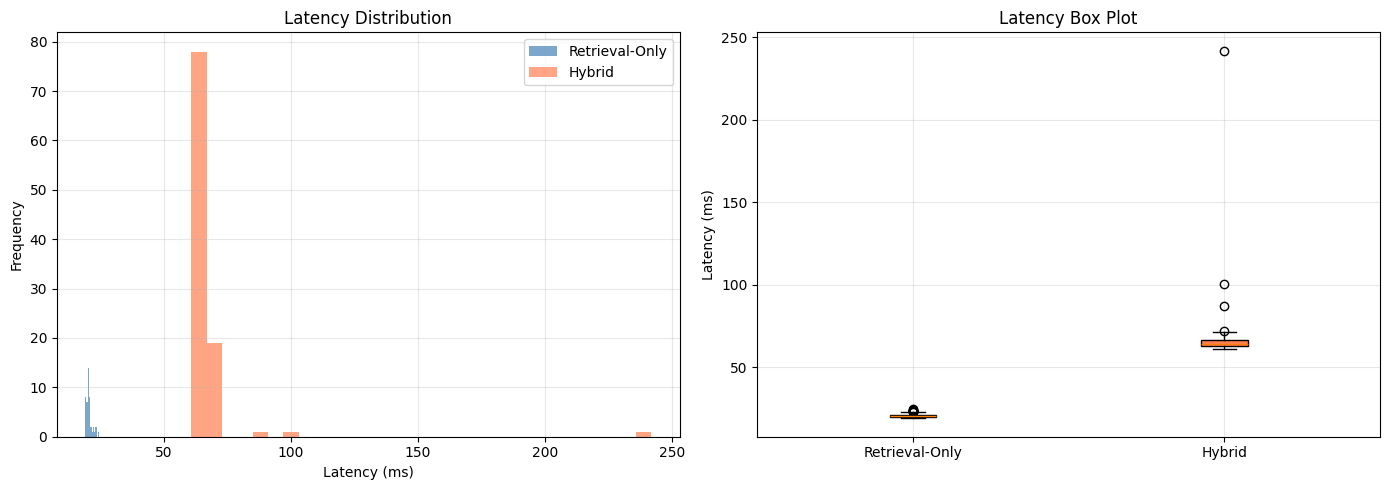

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(retrieval_results['latencies'], bins=30, alpha=0.7, label='Retrieval-Only', color='steelblue')
axes[0].hist(hybrid_results['latencies'], bins=30, alpha=0.7, label='Hybrid', color='coral')
axes[0].set_xlabel('Latency (ms)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Latency Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
box_data = [retrieval_results['latencies'], hybrid_results['latencies']]
bp = axes[1].boxplot(box_data, tick_labels=['Retrieval-Only', 'Hybrid'], patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
axes[1].set_ylabel('Latency (ms)')
axes[1].set_title('Latency Box Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Latency Breakdown Estimate

Based on the benchmark results, we can estimate the component breakdown:

In [13]:
# Estimate component breakdown based on the difference between retrieval and hybrid
retrieval_latency = retrieval_results['mean_ms']
hybrid_latency = hybrid_results['mean_ms']
ranking_overhead = hybrid_latency - retrieval_latency

print("📊 Estimated Component Breakdown (Hybrid Mode)")
print(f"{'='*50}")
print(f"  {'Retrieval (Two-Tower + ANN)':30s}: {retrieval_latency:6.2f} ms ({retrieval_latency/hybrid_latency*100:5.1f}%)")
print(f"  {'Ranking (Features + LightGBM)':30s}: {ranking_overhead:6.2f} ms ({ranking_overhead/hybrid_latency*100:5.1f}%)")
print(f"  {'TOTAL':30s}: {hybrid_latency:6.2f} ms")
print(f"{'='*50}")

# Visual bar
print("\nVisual breakdown:")
retrieval_bar = '█' * int(retrieval_latency / hybrid_latency * 40)
ranking_bar = '▒' * int(ranking_overhead / hybrid_latency * 40)
print(f"  [{retrieval_bar}{ranking_bar}]")
print(f"   █ = Retrieval, ▒ = Ranking")

📊 Estimated Component Breakdown (Hybrid Mode)
  Retrieval (Two-Tower + ANN)   :  20.82 ms ( 30.9%)
  Ranking (Features + LightGBM) :  46.48 ms ( 69.1%)
  TOTAL                         :  67.30 ms

Visual breakdown:
  [████████████▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒]
   █ = Retrieval, ▒ = Ranking


## Summary

Key findings:
- **Retrieval-only** is faster but less accurate
- **Hybrid mode** adds latency from feature generation + LightGBM ranking
- Feature generation is typically the bottleneck in hybrid mode
- The feature store pre-computes entity stats, avoiding expensive `fit()` calls

### Recommendations for Production
1. Consider caching user/recipe features separately
2. Use batch inference for multiple users
3. Pre-compute candidate shortlists for popular users